<a href="https://colab.research.google.com/github/Jef-H/gage_against_the_machine/blob/develop/GageAgainstMachine_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gage Against The Machine 🌊🤖

Welcome to the **Gage Against The Machine** project! 🚀

In this notebook, we are doing Exploratory Data analysis to be upstream for a  supervised regression model.  This model will take features like **temperature, discharge rate, gage height, and nitrate levels** to predict turbidity — and ultimately help us understand how these variables interact in water systems.

We’re using data from the **USGS Turkey River Station** (Site 05412500)

Grab your virtual waders, it’s time to get to work! 🏞️🌟

## Dataset Columns

The dataset contains several key columns, each representing a different aspect of water quality and environmental conditions. Below is a breakdown of the columns and what they represent:

| **Column Name**           | **Description**                                                                                 |
|---------------------------|-------------------------------------------------------------------------------------------------|
| `timestamp`               | The timestamp when the data was recorded (in `YYYY-MM-DD HH:MM` format).                        |
| `turbidity_fbru`          | Turbidity (water clarity) measured in **unfiltered monochrome near infra-red LED light**.       |
| `phosphorus_mg_L`         | Phosphorus concentration in the water, measured in **milligrams per liter** as phosphorus.       |
| `discharge_cfs`           | The **discharge rate** of water (cubic feet per second).                                        |
| `gage_height_ft`          | **Gage height** (in feet), representing the water level at the measurement site.                |
| `nitrate_mg_L`            | **Nitrate plus nitrite** concentration in the water, measured in **milligrams per liter** as nitrogen. |
| `temp_C`                  | The **temperature** of the water (in degrees Celsius).                                          |

---


In [2]:
import pandas as pd

# Define the URL of the dataset
url = "https://github.com/Jef-H/gage_against_the_machine/blob/develop/usgs_station_data_05412500.txt?raw=true"

# Read the file, skipping metadata and correctly handling headers
df = pd.read_csv(
    url,
    sep="\t",
    comment="#",  # Skip metadata lines
    skiprows=34,  # Skip extra format row
    na_values=["", " "],  # Treat empty values as NaN
)

df.rename(columns={
    "datetime": "timestamp",
    "251895_72213": "turbidity_fbru",
    "268036_00665": "phosphorus_mg_L",
    "43604_00060": "discharge_cfs",
    "43606_00065": "gage_height_ft",
    "43610_99133": "nitrate_mg_L",
    "43611_00010": "temp_C"
}
, inplace=True)


# Display first few rows
print(df.head())

  agency_cd   site_no         timestamp tz_cd turbidity_fbru 251895_72213_cd  \
0        5s       15s               20d    6s            14n             10s   
1      USGS  05412500  2020-01-01 00:00   CST            NaN             NaN   
2      USGS  05412500  2020-01-01 00:15   CST            NaN             NaN   
3      USGS  05412500  2020-01-01 00:30   CST            NaN             NaN   
4      USGS  05412500  2020-01-01 00:45   CST            NaN             NaN   

  phosphorus_mg_L 268036_00665_cd discharge_cfs 43604_00060_cd gage_height_ft  \
0             14n             10s           14n            10s            14n   
1             NaN             NaN          2160              A           8.61   
2             NaN             NaN          2160              A           8.61   
3             NaN             NaN          2150              A           8.60   
4             NaN             NaN          2160              A           8.61   

  43606_00065_cd nitrate_mg_L 43

<ipython-input-2-7b5b77ea60c8>:7: DtypeWarning: Columns (1,4,6,7,8,10,12,14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


The first row of data isn't quite data. Lets remove that, and then this import code could be easier to plug and play with other sites, or if we wanted to we could update our timeframe.

In [3]:
# Display the first row
print("First row:")
print(df.head(1))

# Remove the first row
df = df.iloc[1:]

# Display the new first row
print("\nFirst row after removing the original first row:")
print(df.head(1))


First row:
  agency_cd site_no timestamp tz_cd turbidity_fbru 251895_72213_cd  \
0        5s     15s       20d    6s            14n             10s   

  phosphorus_mg_L 268036_00665_cd discharge_cfs 43604_00060_cd gage_height_ft  \
0             14n             10s           14n            10s            14n   

  43606_00065_cd nitrate_mg_L 43610_99133_cd temp_C 43611_00010_cd  
0            10s          14n            10s    14n            10s  

First row after removing the original first row:
  agency_cd   site_no         timestamp tz_cd turbidity_fbru 251895_72213_cd  \
1      USGS  05412500  2020-01-01 00:00   CST            NaN             NaN   

  phosphorus_mg_L 268036_00665_cd discharge_cfs 43604_00060_cd gage_height_ft  \
1             NaN             NaN          2160              A           8.61   

  43606_00065_cd nitrate_mg_L 43610_99133_cd temp_C 43611_00010_cd  
1              A          NaN            NaN    NaN            NaN  


manually deleted this data format line that's mixed in with the data.

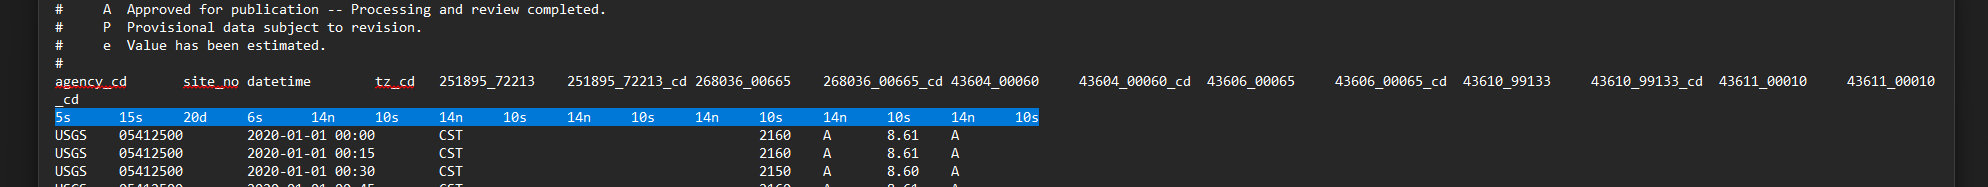

In [4]:
# prompt: Some examples of EDA I would like to see:
# .shape()
# .describe()
# Seaborn pair plot
# Correlation matrix heat map

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your DataFrame is named 'df'
# Replace 'your_file.csv' with the actual path to your file
# df = pd.read_csv('your_file.csv')

print(df.shape)

(180878, 16)


In [5]:
print(df.dtypes)

agency_cd          object
site_no            object
timestamp          object
tz_cd              object
turbidity_fbru     object
251895_72213_cd    object
phosphorus_mg_L    object
268036_00665_cd    object
discharge_cfs      object
43604_00060_cd     object
gage_height_ft     object
43606_00065_cd     object
nitrate_mg_L       object
43610_99133_cd     object
temp_C             object
43611_00010_cd     object
dtype: object


In [6]:
# Convert the relevant columns to numeric, coercing errors to NaN
numeric_columns = [
    'turbidity_fbru', 'phosphorus_mg_L', 'discharge_cfs',
    'gage_height_ft', 'nitrate_mg_L', 'temp_C'
]

df[numeric_columns] = df[numeric_columns].apply(pd.to_numeric, errors='coerce')

# Now check the data types again
print(df.dtypes)

# Check for any NaN values in the numeric columns
print(df[numeric_columns].isnull().sum())


agency_cd           object
site_no             object
timestamp           object
tz_cd               object
turbidity_fbru     float64
251895_72213_cd     object
phosphorus_mg_L    float64
268036_00665_cd     object
discharge_cfs      float64
43604_00060_cd      object
gage_height_ft     float64
43606_00065_cd      object
nitrate_mg_L       float64
43610_99133_cd      object
temp_C             float64
43611_00010_cd      object
dtype: object
turbidity_fbru      78856
phosphorus_mg_L    122852
discharge_cfs       29957
gage_height_ft       4759
nitrate_mg_L        76013
temp_C             115418
dtype: int64


In [7]:
print(df.describe())

       turbidity_fbru  phosphorus_mg_L  discharge_cfs  gage_height_ft  \
count   102022.000000     58026.000000  150921.000000   176119.000000   
mean        55.363657         0.161996    1364.273779        7.432807   
std        157.682264         0.206922    1607.354541        1.600459   
min          1.900000         0.026400     121.000000        5.220000   
25%          8.500000         0.064000     489.000000        6.430000   
50%         16.600000         0.101000     879.000000        7.110000   
75%         40.100000         0.178000    1690.000000        7.990000   
max       3570.000000         3.130000   23000.000000       23.390000   

        nitrate_mg_L        temp_C  
count  104865.000000  65460.000000  
mean        6.159164     12.643818  
std         3.078894      8.675578  
min         0.400000      0.000000  
25%         4.000000      4.800000  
50%         5.400000     12.600000  
75%         7.400000     20.500000  
max        20.000000     32.900000  


Non-numeric values in turbidity_fbru:
1        NaN
2        NaN
3        NaN
4        NaN
5        NaN
          ..
180874   NaN
180875   NaN
180876   NaN
180877   NaN
180878   NaN
Name: turbidity_fbru, Length: 78856, dtype: float64
Non-numeric values in phosphorus_mg_L:
1        NaN
2        NaN
3        NaN
4        NaN
5        NaN
          ..
180874   NaN
180875   NaN
180876   NaN
180877   NaN
180878   NaN
Name: phosphorus_mg_L, Length: 122852, dtype: float64
Non-numeric values in discharge_cfs:
1560     NaN
1561     NaN
1562     NaN
1563     NaN
1564     NaN
          ..
180874   NaN
180875   NaN
180876   NaN
180877   NaN
180878   NaN
Name: discharge_cfs, Length: 29957, dtype: float64
Non-numeric values in gage_height_ft:
7628     NaN
7630     NaN
7631     NaN
7633     NaN
7634     NaN
          ..
180109   NaN
180110   NaN
180111   NaN
180112   NaN
180113   NaN
Name: gage_height_ft, Length: 4759, dtype: float64
Non-numeric values in nitrate_mg_L:
1        NaN
2        NaN
3     

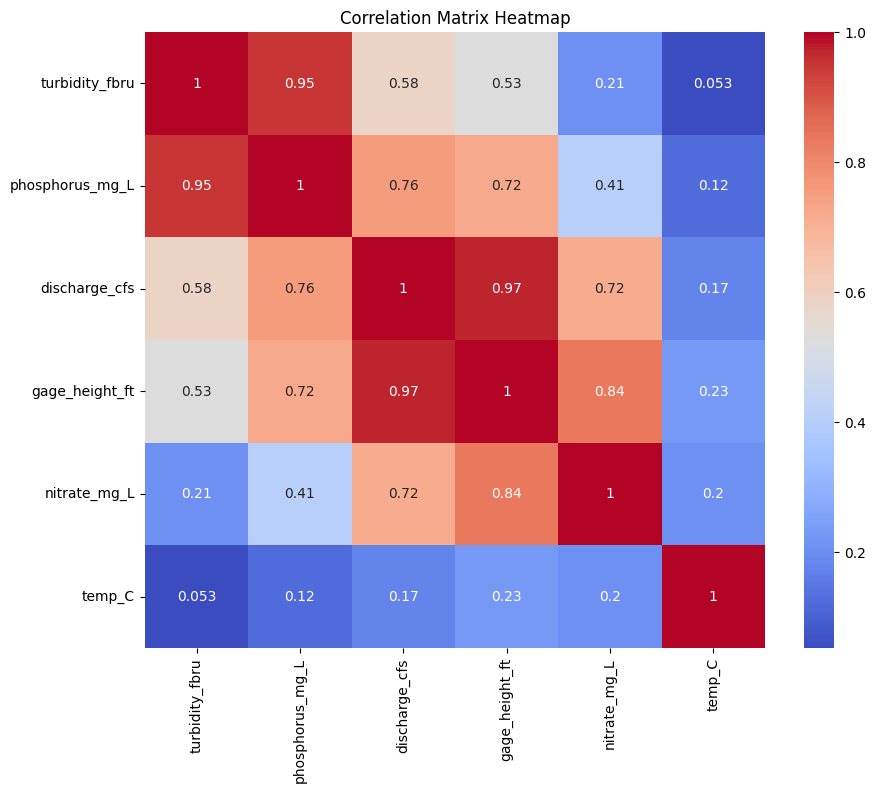

turbidity_fbru     0
phosphorus_mg_L    0
discharge_cfs      0
gage_height_ft     0
nitrate_mg_L       0
temp_C             0
dtype: int64


In [8]:
# Step 1: Identify non-numeric values in the numeric columns
numeric_columns = [
    'turbidity_fbru', 'phosphorus_mg_L', 'discharge_cfs',
    'gage_height_ft', 'nitrate_mg_L', 'temp_C'
]

# Check non-numeric values in the specified columns
for col in numeric_columns:
    print(f"Non-numeric values in {col}:")
    print(df[~df[col].apply(pd.to_numeric, errors='coerce').notnull()][col])

# Step 2: Convert the numeric columns to numeric, coercing errors into NaN
df[numeric_columns] = df[numeric_columns].apply(pd.to_numeric, errors='coerce')

# Step 3: Remove any rows with NaN values in the numeric columns
df_cleaned = df.dropna(subset=numeric_columns)

# Step 4: Check the correlation matrix (exclude non-numeric columns)
# Ensure to exclude any remaining non-numeric columns from the correlation matrix
correlation_matrix = df_cleaned[numeric_columns].corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix Heatmap')
plt.show()

# Optional: Inspect the cleaned data and NaN counts
print(df_cleaned[numeric_columns].isnull().sum())



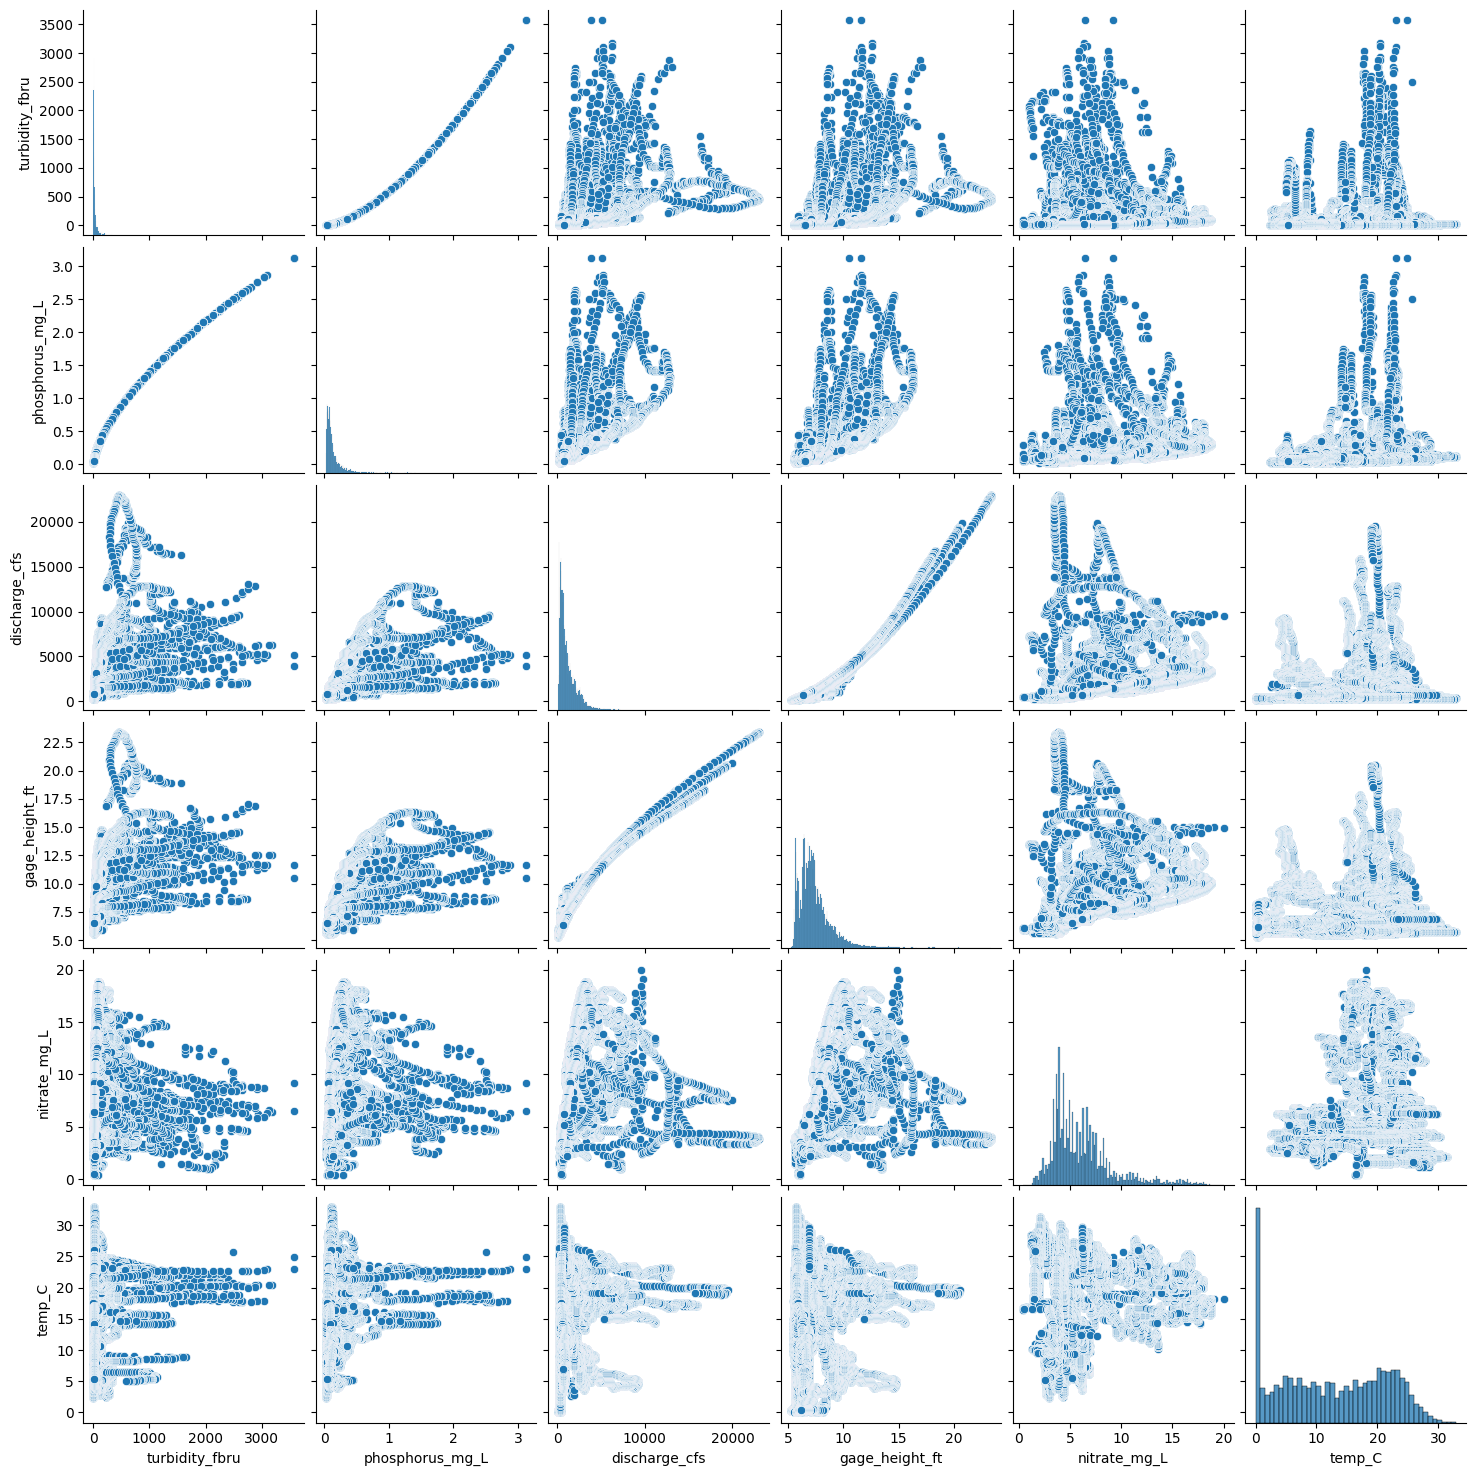

In [9]:

# Pair plot
sns.pairplot(df)
plt.show()